# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 6. Поиск эволюционирующих шаблонов с помощью матричного профиля ряда.**

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib tk
!chcp 65001
!dir

Active code page: 65001
 Volume in drive E has no label.
 Volume Serial Number is 7E48-815E

 Directory of e:\maga\ryads\pr1\25-Chekrygin-TimeSeriesCourse\practice\06 Chains

07.11.2025  22:23    <DIR>          .
22.11.2025  01:23    <DIR>          ..
05.12.2025  19:34            70 414 06 Chains.ipynb
07.11.2025  22:23    <DIR>          datasets
               1 File(s)         70 414 bytes
               3 Dir(s)  332 911 853 568 bytes free


## **Часть 1.** Поиск цепочек временного ряда.

Импорт библиотек и модулей

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import stumpy
from sklearn.metrics import mean_squared_error

В первом задании вам предстоит выполнить поиск эволюционирующих шаблонов временного ряда. Выполните считывание набора данных [Rotation Matrix](datasets/Rotation%20Matrix.txt), найдите в нем самую длинную цепочку и выведите индексы начала звеньев этой цепочки.

In [12]:
fig, ax = plt.subplots(figsize=(16, 2))
ts = np.loadtxt('datasets/Rotation Matrix.txt')
ax.plot(ts)

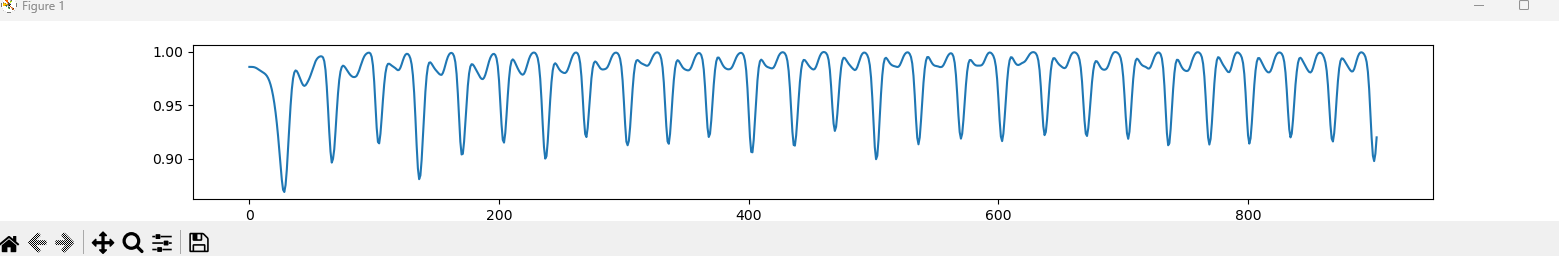

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

ts = np.loadtxt('datasets/Rotation Matrix.txt')

m = int(len(ts) * 0.1)

mp = stumpy.stump(ts, m=m)
nearest = mp[:, 1].astype(int)

n = len(nearest)
adj = [[] for _ in range(n)]
for i, j in enumerate(nearest):
    if 0 <= j < n:
        adj[i].append(j)
        adj[j].append(i)

visited = [False] * n
components = []
for i in range(n):
    if not visited[i]:
        stack = [i]
        comp = []
        visited[i] = True
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in adj[v]:
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        components.append(sorted(comp))

longest_comp = max(components, key=len)
chain_indices = np.array(longest_comp, dtype=int)

fig, ax = plt.subplots(figsize=(16, 2))
ax.plot(ts)
ax.scatter(chain_indices, ts[chain_indices])
plt.show()

print(chain_indices)


[ 11  48 116 382 482 516 550 583 617 781 814]


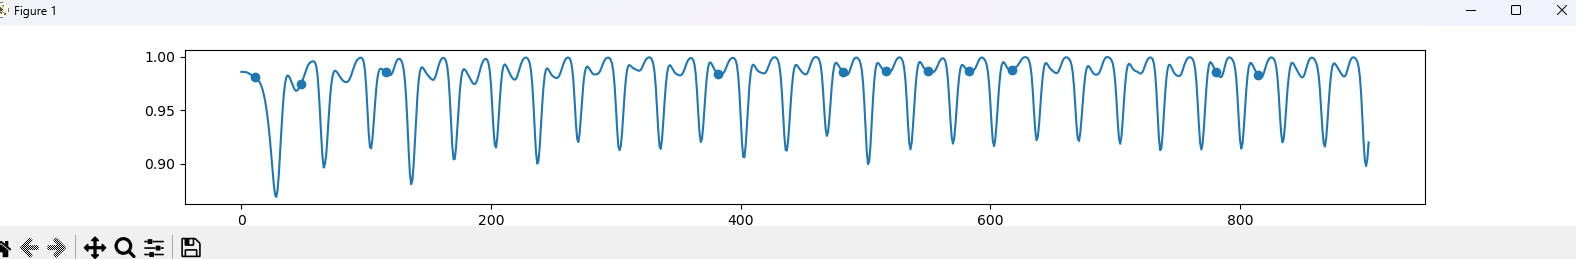

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Найденные индексы обозначают стартовые позиции цепочек в ряду. По сути, эти точки маркируют начало схожих подшаблонов, формирующих последовательные повторяющиеся фрагменты. Однако для дальнейшего анализа и смысла следует визуализировать сами цепочки.

## **Часть 2. Визуализация цепочек**

Выполните визуализацию найденных в прошлом задании цепочек: постройте график временного ряда, на котором выделены звенья цепочек. Также постройте график, на котором изображены только сами звенья.

In [35]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

ts = np.loadtxt('datasets/Rotation Matrix.txt')
m = int(len(ts) * 0.05)

mp = stumpy.stump(ts, m=m)
nearest = mp[:, 1].astype(int)

n = len(nearest)
adj = [[] for _ in range(n)]
for i, j in enumerate(nearest):
    if 0 <= j < n:
        adj[i].append(j)
        adj[j].append(i)

visited = [False] * n
components = []
for i in range(n):
    if not visited[i]:
        stack = [i]
        comp = []
        visited[i] = True
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in adj[v]:
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        components.append(sorted(comp))

longest_comp = max(components, key=len)
chain_indices = np.array(longest_comp, dtype=int)

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(ts, color='blue')
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='orange')
plt.show()

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(ts, color='white')
for idx in chain_indices:
    ax.plot(range(idx, idx + m), ts[idx:idx + m], color='orange')
plt.show()


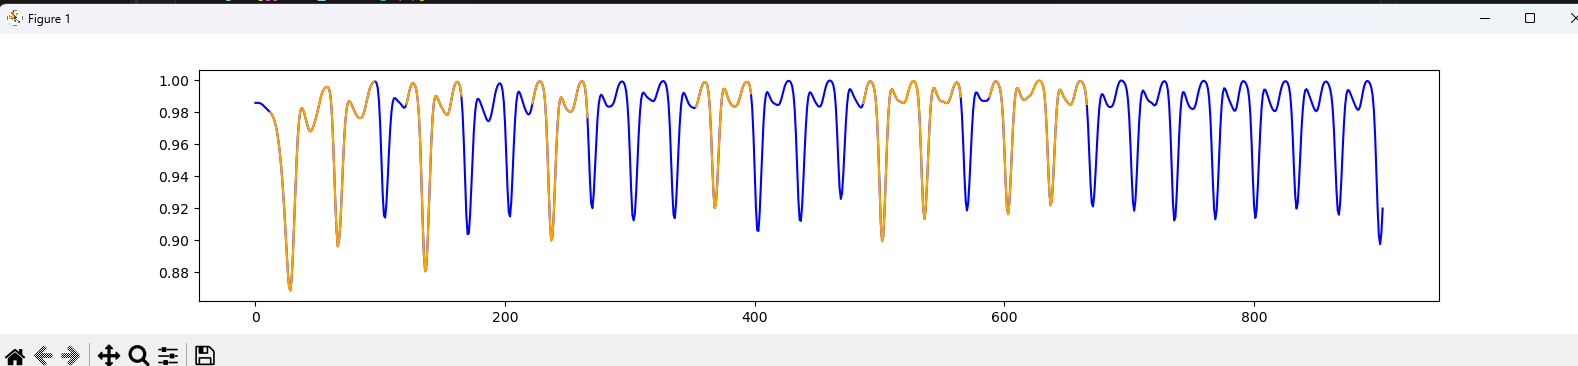

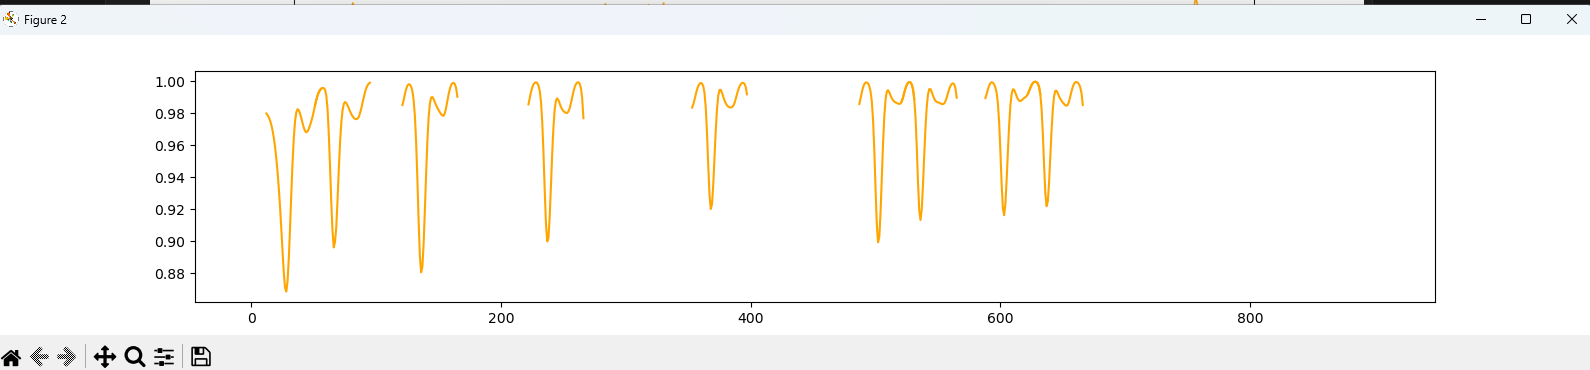

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Индексы цепочек соответствуют стартовым позициям звеньев. Как и ожидалось, цепочки обладают крайне высокой схожестью, были найдены последовательности

## **Часть 3.** Предсказывание значений ряда на основе цепочек.

Предскажите значения последнего звена цепочки, вычислив разность между двумя предыдущими звеньями цепочки. Сравните полученное предсказание с истинным значением.

In [37]:
import numpy as np
import matplotlib.pyplot as plt
import stumpy

ts = np.loadtxt('datasets/Rotation Matrix.txt')
m = int(len(ts) * 0.1)

mp = stumpy.stump(ts, m=m)
nearest = mp[:, 1].astype(int)

n = len(nearest)
adj = [[] for _ in range(n)]
for i, j in enumerate(nearest):
    if 0 <= j < n:
        adj[i].append(j)
        adj[j].append(i)

visited = [False] * n
components = []
for i in range(n):
    if not visited[i]:
        stack = [i]
        comp = []
        visited[i] = True
        while stack:
            v = stack.pop()
            comp.append(v)
            for u in adj[v]:
                if not visited[u]:
                    visited[u] = True
                    stack.append(u)
        components.append(sorted(comp))

longest_comp = max(components, key=len)
chain_indices = np.array(longest_comp, dtype=int)

seg_prev2 = ts[chain_indices[-3] : chain_indices[-3] + m]
seg_prev1 = ts[chain_indices[-2] : chain_indices[-2] + m]
seg_true  = ts[chain_indices[-1] : chain_indices[-1] + m]

diff = seg_prev1 - seg_prev2
seg_pred = seg_prev1 + diff

fig, ax = plt.subplots(figsize=(16, 3))
ax.plot(seg_true, label='истинное', color='blue')
ax.plot(seg_pred, label='предсказанное', color='orange')
ax.legend()
plt.show()

print(seg_pred)
print(seg_true)


[0.9839801  0.97969485 0.9754931  0.97220043 0.97131655 0.97421574
 0.98050117 0.98806156 0.99430214 0.99803596 0.9994188  0.9991312
 0.9978435  0.9958916  0.99285443 0.98704334 0.97558596 0.95640566
 0.9324914  0.91303434 0.90606496 0.91301274 0.92974077 0.9499402
 0.9685843  0.98245266 0.99079035 0.99427603 0.9943231  0.99238337
 0.9895137  0.98631536 0.98304362 0.98004546 0.97783177 0.97671831
 0.9769066  0.97865616 0.982111   0.986521   0.9910555  0.99478612
 0.99733197 0.9987732  0.99939096 0.99932796 0.9983296  0.9954601
 0.98872714 0.97580076 0.9561335  0.93459578 0.91947424 0.91642996
 0.92546325 0.9435645  0.96361413 0.98123157 0.99103624 0.9970337
 0.9988504  0.9977424  0.9953775  0.9929026  0.9905951  0.9880509
 0.98500892 0.98178374 0.97909175 0.9778582  0.97900945 0.98273788
 0.98778787 0.99228985 0.99611996 0.99791773 0.99868322 0.9986107
 0.99764684 0.99553606 0.9916317  0.98627526 0.97660826 0.9610409
 0.94147527 0.92359709 0.9135048  0.9135204  0.92248294 0.9375784 ]
[

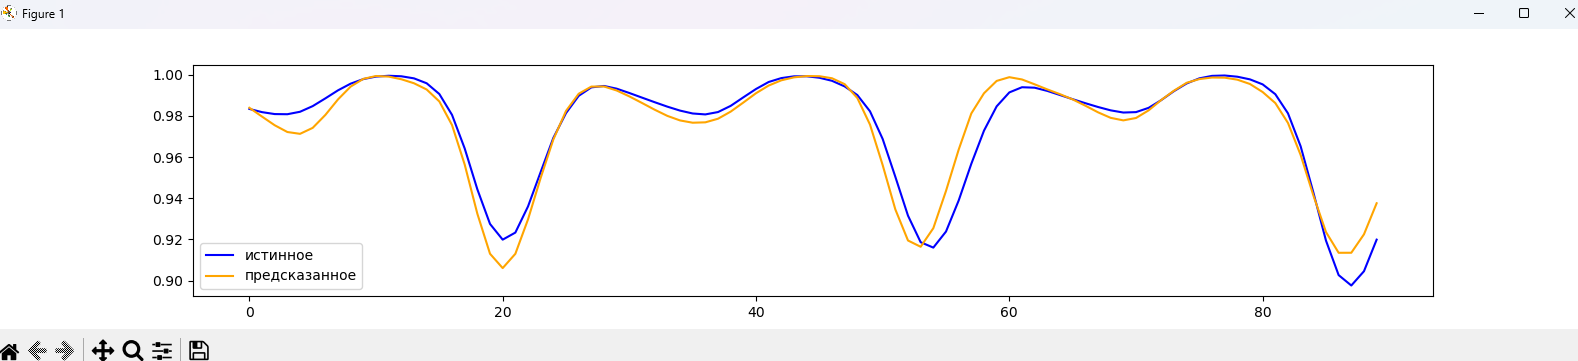

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

 В целом, предсказанный фрагмент неплохо держит контур истинного сегмента. В некоторых местах возникают расхождения, т.к. предсказание основывается на экстраполяции, но эволюция данных в ряде нелинейна.